In [1]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Mounted at /content/gdrive/
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [2]:
import pandas as pd
import joblib
data = pd.read_csv("AMZN_VADER_SCORE_READY_FOR_TRAINING.csv")
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008


In [3]:
days = 60

In [4]:
amzn_data = data[['Close']]
amzn_data.head()

,Close
0,159.524506
1,161.195496
2,157.597000
3,158.073502
4,161.145004


In [5]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562]
 [161.19549561]
 [157.59700012]
 [158.07350159]
 [161.14500427]
 [163.51950073]
 [161.61399841]
 [161.58999634]
 [162.38400269]
 [160.15400696]
 [162.24949646]
 [162.95249939]
 [163.25799561]
 [161.50549316]
 [161.15350342]
 [160.93249512]
 [161.69949341]
 [159.35049438]
 [160.31100464]
 [159.90049744]
 [163.20550537]
 [164.05749512]
 [167.48249817]
 [167.34150696]
 [169.1934967 ]
 [169.15649414]
 [170.76249695]
 [174.46200562]
 [174.34500122]
 [172.69799805]
 [175.27200317]
 [175.19099426]
 [172.45399475]
 [170.07299805]
 [172.19450378]
 [172.40699768]
 [172.00799561]
 [171.64849854]
 [175.54899597]
 [183.78700256]
 [184.82899475]
 [186.57049561]
 [185.96699524]
 [185.92750549]
 [183.86799622]
 [184.08399963]
 [181.55999756]
 [178.6815033 ]
 [177.47950745]
 [178.65950012]
 [179.25999451]
 [181.90150452]
 [182.83200073]
 [184.99099731]
 [181.31950378]
 [181.51600647]
 [179.9960022 ]
 [166.37950134]
 [166.57400513]
 [168.31199646]
 [167.73599243]
 [168.79949951]
 [167.24

In [6]:
amzn_comp_len = int(len(amzn_data_array) *0.8)
print(amzn_comp_len)

785


In [7]:
training_data = amzn_data_array[0:amzn_comp_len]
print(training_data)
print('\n')
print("\n")
print(type(training_data))

[[159.52450562]
 [161.19549561]
 [157.59700012]
 [158.07350159]
 [161.14500427]
 [163.51950073]
 [161.61399841]
 [161.58999634]
 [162.38400269]
 [160.15400696]
 [162.24949646]
 [162.95249939]
 [163.25799561]
 [161.50549316]
 [161.15350342]
 [160.93249512]
 [161.69949341]
 [159.35049438]
 [160.31100464]
 [159.90049744]
 [163.20550537]
 [164.05749512]
 [167.48249817]
 [167.34150696]
 [169.1934967 ]
 [169.15649414]
 [170.76249695]
 [174.46200562]
 [174.34500122]
 [172.69799805]
 [175.27200317]
 [175.19099426]
 [172.45399475]
 [170.07299805]
 [172.19450378]
 [172.40699768]
 [172.00799561]
 [171.64849854]
 [175.54899597]
 [183.78700256]
 [184.82899475]
 [186.57049561]
 [185.96699524]
 [185.92750549]
 [183.86799622]
 [184.08399963]
 [181.55999756]
 [178.6815033 ]
 [177.47950745]
 [178.65950012]
 [179.25999451]
 [181.90150452]
 [182.83200073]
 [184.99099731]
 [181.31950378]
 [181.51600647]
 [179.9960022 ]
 [166.37950134]
 [166.57400513]
 [168.31199646]
 [167.73599243]
 [168.79949951]
 [167.24

In [8]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978]
 [0.67164914]
 [0.64119987]
 [0.64523186]
 [0.6712219 ]
 [0.6913141 ]
 [0.67519037]
 [0.67498728]
 [0.6817059 ]
 [0.66283641]
 [0.68056775]
 [0.68651633]
 [0.68910133]
 [0.67427224]
 [0.67129382]
 [0.66942372]
 [0.67591381]
 [0.65603735]
 [0.66416487]
 [0.6606913 ]
 [0.68865718]
 [0.69586643]
 [0.72484768]
 [0.72365465]
 [0.73932558]
 [0.73901247]
 [0.75260194]
 [0.78390595]
 [0.7829159 ]
 [0.76897951]
 [0.79075989]
 [0.79007441]
 [0.76691483]
 [0.74676763]
 [0.76471911]
 [0.76651716]
 [0.76314093]
 [0.76009899]
 [0.79310371]
 [0.86281099]
 [0.87162798]
 [0.88636398]
 [0.88125736]
 [0.88092321]
 [0.86349633]
 [0.86532408]
 [0.84396681]
 [0.81960995]
 [0.80943905]
 [0.81942376]
 [0.82450495]
 [0.84685653]
 [0.85473008]
 [0.87299879]
 [0.84193183]
 [0.84359457]
 [0.8307328 ]
 [0.71551448]
 [0.71716031]
 [0.73186661]
 [0.72699266]
 [0.7359917 ]
 [0.72285492]
 [0.72155615]
 [0.71259093]
 [0.70050346]
 [0.70532242]
 [0.70129042]
 [0.70341423]
 [0.6792859 ]
 [0.65635046]
 [0.66

In [9]:
test = amzn_data[amzn_comp_len :]
print(test.shape)

(197, 1)


In [10]:
test_inputs = amzn_data_array[len(amzn_data_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 1)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 1)
Test inputs with a reshape : (257, 1)
Test inputs after transformed : (257, 1)


In [11]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,0])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {60} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [12]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60)
(725, 1)


In [13]:
X_test = []
y_test = amzn_data_array[amzn_comp_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, 0])

In [14]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 1)
725
60


In [15]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],1))
print(X_test.shape)

(197, 60)
(197, 60, 1)


In [16]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model = Sequential()
model.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 1), activation='tanh'))
model.add(Dropout(0.2))
model.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model.add(Dropout(0.2))
model.add(LSTM(units = 100, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,101 (1.08 MB)

 Trainable params: 282,101 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
seed = 412
np.random.seed(seed)
tf.random.set_seed(seed)
history1 = model.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1044 - mae: 0.2379
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0133 - mae: 0.0895
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0098 - mae: 0.0773
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0074 - mae: 0.0673
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0077 - mae: 0.0687
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0073 - mae: 0.0663
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0085 - mae: 0.0722
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0067 - mae: 0.0629
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0083 - mae: 0.0709
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0068 - mae: 0.0638
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057 - mae: 0.0592
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066 - mae: 0.0630
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

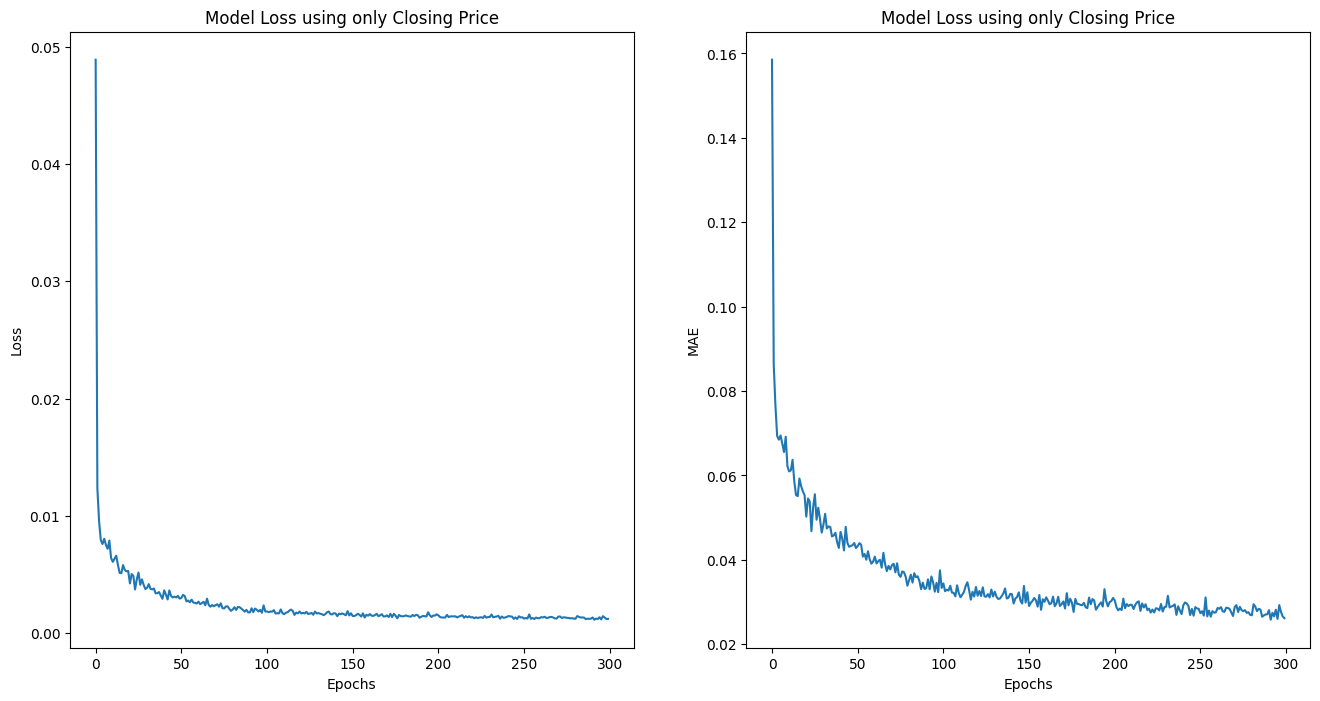

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label = 'Training Loss')
plt.title("Model Loss using only Closing Price")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history1.history['mae'], label = 'Mean Absolute Error')
plt.title("Model Loss using only Closing Price")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [19]:
predictions = model.predict(X_test)
predictions = x_scaler.inverse_transform(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


In [20]:
rmse = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse)

6.965289508025658


In [21]:
dates = data['Date']

<ipython-input-23-9f5acb489212>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_comp_len]
<ipython-input-23-9f5acb489212>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_comp_len:]
<ipython-input-23-9f5acb489212>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

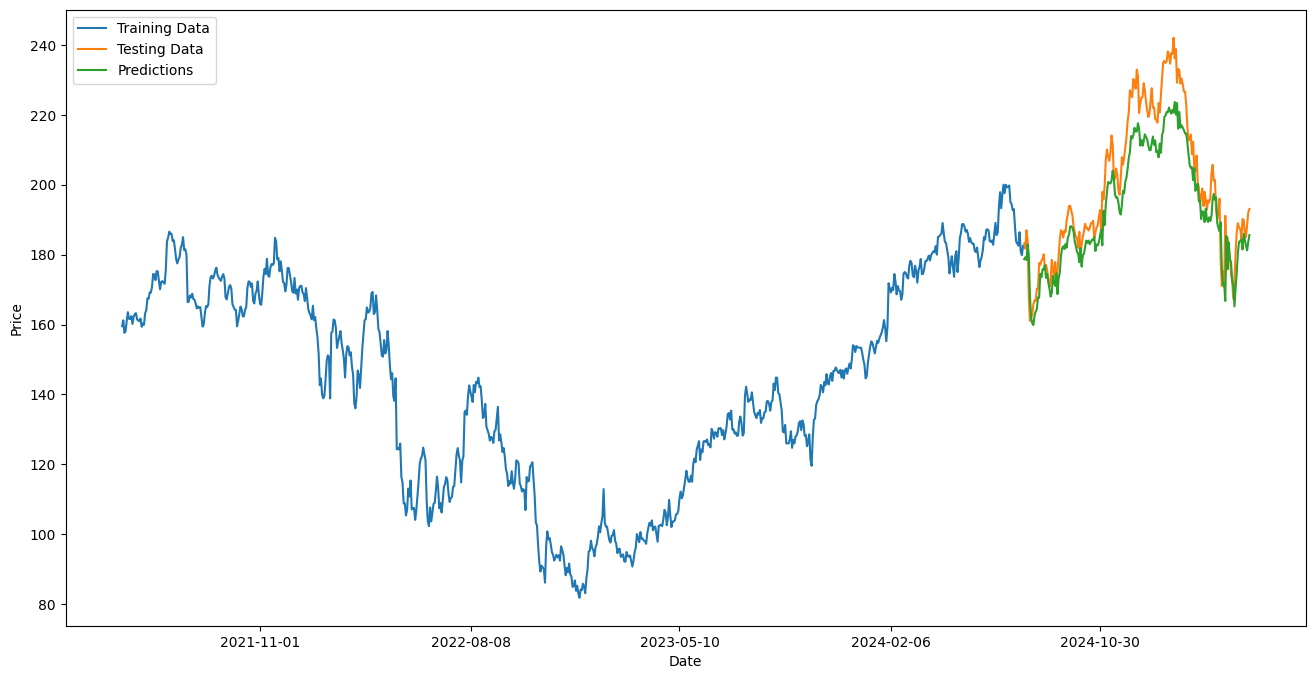

In [23]:
train = amzn_data[:amzn_comp_len]
train['Date'] = dates[:amzn_comp_len]
testing = amzn_data[amzn_comp_len:]
testing['Date'] = dates[amzn_comp_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close'], label = "Training Data")
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [24]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [25]:
joblib.dump(model,'Base_model')

['Base_model']